# Model comparison — representation × model × seed benchmark


## Goal
Run a reproducible benchmark matrix across three prepared representations, multiple classical model families, repeated seeds and a dummy baseline. The notebook builds a leaderboard, stability table, rank analysis and runtime comparison from `BenchmarkResult` rather than hand-assembling model loops.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("SABER_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from saber import benchmark
from saber.benchmark import BenchmarkConfig
from saber.datasets import DatasetBundle, PartitionPlan


In [2]:
rng = np.random.default_rng(21)
n_samples = 120 if DEMO_TEST else 300
X, y = make_classification(n_samples=n_samples, n_features=12, n_informative=8, n_redundant=2,
                           class_sep=1.1, random_state=21)
ids = [f"cmp_{i:04d}" for i in range(len(y))]
compact = DatasetBundle(X=X, y=y, sample_ids=ids, feature_names=[f"compact_{i}" for i in range(X.shape[1])])
expanded_X = np.column_stack([X, rng.normal(size=(len(y), 18))])
expanded = DatasetBundle(X=expanded_X, y=y, sample_ids=ids, feature_names=[f"expanded_{i}" for i in range(expanded_X.shape[1])])
compressed_X = X[:, :6] + 0.05*rng.normal(size=(len(y),6))
compressed = DatasetBundle(X=compressed_X, y=y, sample_ids=ids, feature_names=[f"compressed_{i}" for i in range(6)])
plan = PartitionPlan.from_predefined_folds(sample_ids=ids, fold_assignments=balanced_fold_labels(y,4),
                                           dataset_fingerprint=compact.fingerprint)


In [3]:
seeds = (42,) if DEMO_TEST else (42,123,777)
bench = benchmark(
    datasets={"compact":compact, "expanded_noisy":expanded, "compressed":compressed},
    algorithms=("logistic_regression", "random_forest", "svc"),
    partitions={"prepared_4fold":plan},
    config=BenchmarkConfig(metrics=("mcc","balanced_accuracy","f1","roc_auc"),
                           seeds=seeds, modes=("untuned",), include_baselines=True),
    model_params={"random_forest":{"n_estimators":50 if DEMO_TEST else 120,"max_depth":7}},
)
assert not bench.failures
metrics = bench.aggregate_metrics_frame(); runs=bench.runs_frame(); preds=bench.predictions_frame()
leader = (metrics[metrics.metric=="mcc"].groupby(["representation","algorithm"])["score"]
          .agg(["mean","std","min","max"]).reset_index())
leader["rank_within_representation"] = leader.groupby("representation")["mean"].rank(ascending=False, method="dense")
leader.sort_values(["representation","rank_within_representation"])


,representation,algorithm,mean,std,min,max,rank_within_representation
3,compact,svc,0.716457,0.000000,0.716457,0.716457,1.0
2,compact,random_forest,0.634461,0.010426,0.627025,0.646379,2.0
1,compact,logistic_regression,0.454631,0.000000,0.454631,0.454631,3.0
0,compact,dummy_classifier,0.000000,0.000000,0.000000,0.000000,4.0
7,compressed,svc,0.506973,0.000000,0.506973,0.506973,1.0
6,compressed,random_forest,0.404375,0.013444,0.393599,0.419441,2.0
4,compressed,dummy_classifier,0.000000,0.000000,0.000000,0.000000,3.0
5,compressed,logistic_regression,-0.006250,0.000000,-0.006250,-0.006250,4.0
11,expanded_noisy,svc,0.574500,0.000000,0.574500,0.574500,1.0
10,expanded_noisy,random_forest,0.553683,0.003320,0.549859,0.555824,2.0


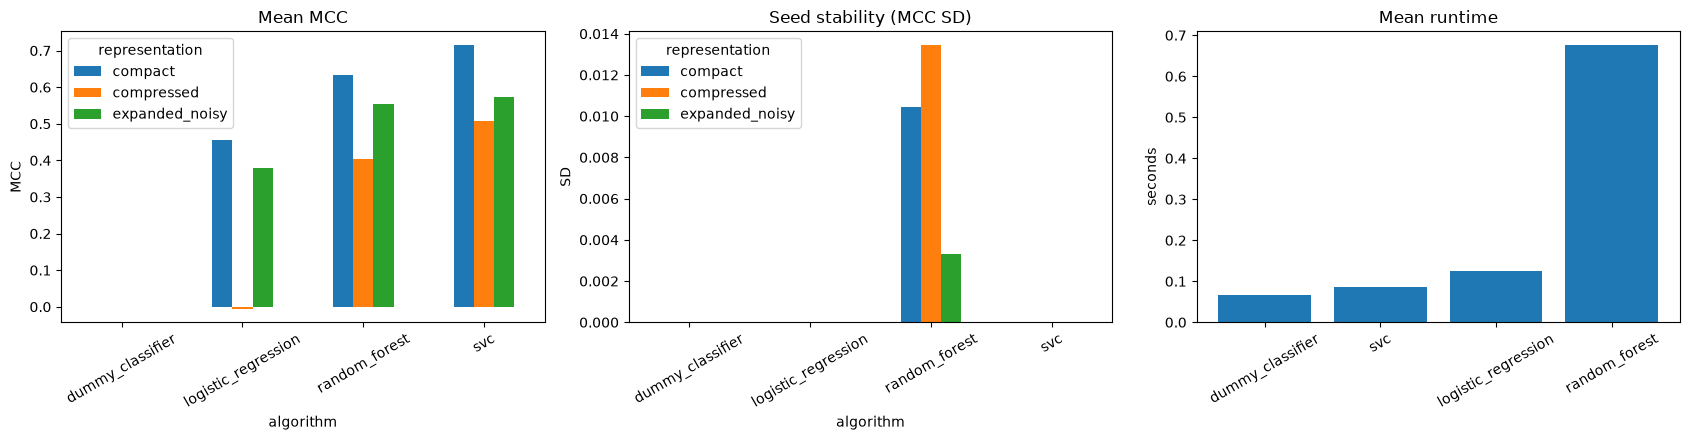

In [4]:
fig, axes = plt.subplots(1,3,figsize=(17,4.5))
leader.pivot(index="algorithm",columns="representation",values="mean").plot.bar(ax=axes[0])
axes[0].set(title="Mean MCC", ylabel="MCC"); axes[0].tick_params(axis="x",rotation=30)
leader.pivot(index="algorithm",columns="representation",values="std").plot.bar(ax=axes[1])
axes[1].set(title="Seed stability (MCC SD)", ylabel="SD"); axes[1].tick_params(axis="x",rotation=30)
runtime=runs.groupby("algorithm")["elapsed_seconds"].mean().sort_values()
axes[2].bar(runtime.index,runtime.values); axes[2].set(title="Mean runtime",ylabel="seconds"); axes[2].tick_params(axis="x",rotation=30)
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
expected = 3 * 4 * len(seeds)  # three representations × baseline+3 models × seeds
DEMO_CHECKS = {
    "matrix_complete": bench.n_runs == expected,
    "no_failures": len(bench.failures)==0,
    "metric_panel": set(metrics.metric.unique()) == {"mcc","balanced_accuracy","f1","roc_auc"},
    "predictions_traceable": set(preds.run_id)==set(runs.run_id),
    "leaderboard_complete": len(leader)==12,
    "rank_available": leader.rank_within_representation.notna().all(),
    "figure_created": FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'matrix_complete': True,
 'no_failures': True,
 'metric_panel': True,
 'predictions_traceable': True,
 'leaderboard_complete': True,
 'rank_available': np.True_,
 'figure_created': True}